# 04 — Dataset Acquisition

Three-step pipeline to build a labeled training dataset:

| Step | Source | What you get |
|------|--------|--------------|
| **1** | `samsilverman/PSA-Grades-Baseball` | 11,500 balanced baseball images, grades 1–10 |
| **2** | PSA Cert API | Pokémon card photos + exact grades (post-Oct 2021) |
| **3** | eBay Browse API | Active listing images, grade parsed from title |
| **4** | Merge + train | Unified dataset → ResNet-18 (see `03_saliency_explainability.ipynb`) |

**No prerequisites** — this notebook is fully standalone.

## Setup

In [1]:
# ── Install dependencies ─────────────────────────────────────────
import subprocess, sys
packages = ['opencv-python','numpy','matplotlib','requests','tqdm']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)

import cv2, numpy as np
from pathlib import Path
from collections import defaultdict, Counter

# GRADE_COLORS for the distribution plot (mirrors grading_utils)
GRADE_COLORS = {
    10:'#22c55e', 9:'#4ade80', 8:'#86efac',
     7:'#fbbf24', 6:'#fb923c', 5:'#f97316',
     4:'#ef4444', 3:'#dc2626', 2:'#b91c1c', 1:'#7f1d1d',
}

# PSA bucket mapping (mirrors 03 / resnet pipeline)
PSA_TO_BUCKET  = {1:0,2:0, 3:1,4:1, 5:2,6:2, 7:3,8:3, 9:4,10:4}
BUCKET_NAMES   = ['Poor','Very Good','Excellent','Near Mint','Mint']

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.facecolor']  = '#0d1117'
plt.rcParams['figure.facecolor']= '#0d1117'
plt.rcParams['text.color']      = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color']     = 'white'
plt.rcParams['ytick.color']     = 'white'

print('✅ Dataset acquisition notebook ready')

✅ Dataset acquisition notebook ready


---
## Recommended Path — Building a Training Dataset

Three complementary sources, each with a dedicated section:

| Step | Source | Images | Auth needed | Time |
|------|--------|--------|-------------|------|
| **26** | `samsilverman/PSA-Baseball-Grades` | 11,500 balanced | None | 5 min |
| **27** | PSA Cert API (Pokémon, post-Oct 2021) | 1K–50K | Free PSA account | Days–weeks |
| **28** | eBay Browse API (active listings) | Hundreds/run | `EBAY_APP_ID` | Minutes |
| **29** | Merge + organize + train | All of the above | — | — |

---
## 26. Step 1 — Download Open Datasets

No authentication, no scraping — just `git clone`.

In [2]:
import subprocess, shutil
from pathlib import Path

DATASET_ROOT = Path('datasets')
DATASET_ROOT.mkdir(exist_ok=True)


# ── A. PSA-Baseball-Grades  (11,500 images, grades 1-10) ─────────
BASEBALL_DIR = DATASET_ROOT / 'PSA-Grades-Baseball'
if not BASEBALL_DIR.exists():
    print('Cloning PSA-Grades-Baseball (~150 MB) …')
    subprocess.run([
        'git', 'clone', '--depth=1',
        'https://github.com/samsilverman/PSA-Grades-Baseball.git',
        str(BASEBALL_DIR),
    ], check=True)
    print('✅ Done')
else:
    print(f'✅ Already present: {BASEBALL_DIR}')

# Count what we got
for grade in range(1, 11):
    folder = BASEBALL_DIR / f'psa{grade}'
    n = len(list(folder.glob('*.jpg'))) if folder.exists() else 0
    bar = '█' * (n // 115)
    print(f'  PSA {grade:>2}: {n:>5} images  {bar}')


# ── B. psa_pokemon_cards model code (no bundled data — code only) ─
POKEMON_DIR = DATASET_ROOT / 'psa_pokemon_cards'
if not POKEMON_DIR.exists():
    print('\nCloning psa_pokemon_cards (model code only — ~5 MB) …')
    subprocess.run([
        'git', 'clone', '--depth=1',
        'https://github.com/crimsonthinker/psa_pokemon_cards.git',
        str(POKEMON_DIR),
    ], check=True)
    print('✅ Done')
else:
    print(f'\n✅ Already present: {POKEMON_DIR}')

print('\nNote: psa_pokemon_cards ships no images — it is a reference')
print('architecture only. Populate datasets/pokemon/ via Sections 27-28.')

✅ Already present: datasets/PSA-Grades-Baseball
  PSA  1:  1150 images  ██████████
  PSA  2:  1150 images  ██████████
  PSA  3:  1150 images  ██████████
  PSA  4:  1150 images  ██████████
  PSA  5:  1150 images  ██████████
  PSA  6:  1150 images  ██████████
  PSA  7:  1150 images  ██████████
  PSA  8:  1150 images  ██████████
  PSA  9:  1150 images  ██████████
  PSA 10:  1150 images  ██████████

✅ Already present: datasets/psa_pokemon_cards

Note: psa_pokemon_cards ships no images — it is a reference
architecture only. Populate datasets/pokemon/ via Sections 27-28.


## 27. Step 2 — PSA Cert API Scraper

**Endpoint:** `https://api.psacard.com/publicapi/cert/GetByCertNumber/{cert}`  
**Auth:** Bearer token (free account at psacard.com/publicapi)  
**Rate limit:** 100 calls / day free (≈ 50 certs/day using both detail + image endpoints)

### Strategy
PSA cert numbers are sequential 8-digit integers. Cards graded **after October 2021**
have front + back photos in the database. The scraper:

1. Takes an **anchor cert** you already know (any slab you own — scan the barcode)
2. Scans outward ± `scan_radius` certs from that anchor
3. Filters by `target_brand` (e.g. `"Pokemon"`) so only relevant cards are saved
4. Respects the daily quota — writes a `quota.json` counter that persists across runs
5. Resumes automatically — skips certs already downloaded

In [ ]:
import os, json as _json, re as _re, time, requests
from pathlib import Path
from datetime import date

# ── CONFIG — fill these in ────────────────────────────────────────
PSA_TOKEN    = os.getenv('PSA_API_TOKEN', '344UAunWpkPZ1HNOLbTESXSu-jh9UrCE3RuOzZgHATWn6fo50XAh9UMw8RYR_W_YaMbhFGi5Q8_ISCADeWd1_z6F6f7DWHni02vxFjPn2_wz1TaQ8k8Lo9-y5mMxg7CC0XWeV4X_6KWCbdeV5hBdiajaa1EXeAQusfNZapyYBop5NSASFMvJYd8pW7QpPi7sY8c6UP6hTrpWlHV0RFphFGAKJFJGPMpjIimvpP4D-gEG9P3xUc4-smoTPd8aglq9Cj76bTI036G7KgWfB4D90JX3B-RFF1YwhTMsmQwhQ3o-WNSt')
ANCHOR_CERT  = ''          # cert # from any PSA slab, e.g. '84053585'
SCAN_RADIUS  = 5_000       # scan ± this many certs from anchor
TARGET_BRAND = 'Pokemon'   # filter: only save cards matching this brand
SAVE_DIR     = Path('datasets/pokemon_psa')
DAILY_LIMIT  = 90          # stay under the 100-call/day free tier
# ─────────────────────────────────────────────────────────────────

SAVE_DIR.mkdir(parents=True, exist_ok=True)
QUOTA_FILE = SAVE_DIR / 'quota.json'
META_FILE  = SAVE_DIR / 'metadata.csv'


def _load_quota() -> dict:
    today = str(date.today())
    if QUOTA_FILE.exists():
        q = _json.loads(QUOTA_FILE.read_text())
        if q.get('date') == today:
            return q
    return {'date': today, 'calls': 0}


def _save_quota(q: dict):
    QUOTA_FILE.write_text(_json.dumps(q))


def _psa_get(path: str, token: str):
    url = f'https://api.psacard.com/publicapi/{path}'
    try:
        r = requests.get(url, headers={'authorization': f'bearer {token}'}, timeout=10)
        if r.status_code == 200:
            return r.json()
        if r.status_code == 429:
            print('  ⚠ Rate-limited — stopping for today')
            return 'RATE_LIMIT'
    except requests.RequestException as e:
        print(f'  Network error: {e}')
    return None


def _download_image(url: str, dest: Path) -> bool:
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            dest.write_bytes(r.content)
            return True
    except requests.RequestException:
        pass
    return False


def _extract_grade(cert_obj: dict) -> int | None:
    """
    Extract a numeric PSA grade (1-10) from a PSACert dict.

    PSA API returns GradeDescription like "GEM MT 10", "NM-MT 8", "PR 1".
    Also tries direct numeric fields as fallback.
    """
    # Try description fields — grade number is always the last token
    for field in ('GradeDescription', 'Grade', 'CardGrade'):
        desc = str(cert_obj.get(field, '') or '').strip()
        if desc:
            m = _re.search(r'\b(10|[1-9])$', desc)
            if m:
                g = int(m.group(1))
                if 1 <= g <= 10:
                    return g
    # Try bare numeric fields
    for field in ('PSAGrade', 'NumericGrade', 'Grade', 'CardGrade'):
        val = cert_obj.get(field)
        if val is not None:
            try:
                g = int(str(val).split('.')[0])
                if 1 <= g <= 10:
                    return g
            except (ValueError, TypeError):
                pass
    return None


def fetch_cert(cert_num: int, token: str):
    cert_str = str(cert_num)

    data = _psa_get(f'cert/GetByCertNumber/{cert_str}', token)
    if data == 'RATE_LIMIT':
        return 'RATE_LIMIT'
    if not data:
        return None

    cert = data.get('PSACert', {})
    brand = (cert.get('Brand', '') or cert.get('Variety', '') or '').strip()

    if TARGET_BRAND.lower() not in brand.lower():
        return None

    grade = _extract_grade(cert)
    if grade is None:
        return None

    imgs = _psa_get(f'cert/GetImagesByCertNumber/{cert_str}', token)
    if imgs == 'RATE_LIMIT':
        return 'RATE_LIMIT'
    if not imgs:
        return None

    saved_paths = {}
    for img_obj in (imgs if isinstance(imgs, list) else []):
        url      = img_obj.get('ImageURL', '')
        is_front = img_obj.get('IsFrontImage', True)
        if not url:
            continue
        side = 'front' if is_front else 'back'
        dest = SAVE_DIR / f'psa{grade}' / f'{cert_str}_{side}.jpg'
        dest.parent.mkdir(parents=True, exist_ok=True)
        if not dest.exists():
            _download_image(url, dest)
        saved_paths[side] = str(dest)

    if not saved_paths:
        return None

    return {
        'cert':    cert_str,
        'grade':   grade,
        'brand':   brand,
        'subject': cert.get('Subject', ''),
        'year':    cert.get('Year', ''),
        'set':     cert.get('Variety', ''),
        'card_no': cert.get('CardNumber', ''),
        **{f'path_{k}': v for k, v in saved_paths.items()},
    }


def scrape_psa(anchor_cert: str = ANCHOR_CERT,
               scan_radius: int = SCAN_RADIUS,
               token: str       = PSA_TOKEN,
               max_new: int     = 200) -> list[dict]:
    if not token:
        print('⚠ PSA_API_TOKEN not set.'); return []
    if not anchor_cert:
        print('⚠ ANCHOR_CERT not set.'); return []

    done_certs = set()
    if META_FILE.exists():
        import csv
        with open(META_FILE, newline='') as f:
            done_certs = {row['cert'] for row in csv.DictReader(f)}
    print(f'Already collected: {len(done_certs)} certs')

    quota     = _load_quota()
    results   = []
    new_count = 0
    anchor    = int(anchor_cert)
    offsets   = [o for d in range(scan_radius + 1) for o in ([d, -d] if d else [0])]

    for offset in offsets:
        cert_num = anchor + offset
        if cert_num < 1:
            continue
        cert_str = str(cert_num)
        if cert_str in done_certs:
            continue
        if new_count >= max_new:
            print(f'Reached max_new={max_new} — stopping this run'); break
        if quota['calls'] >= DAILY_LIMIT:
            print(f'Daily quota ({DAILY_LIMIT}) reached — resume tomorrow'); break

        quota['calls'] += 2
        _save_quota(quota)

        result = fetch_cert(cert_num, token)
        if result == 'RATE_LIMIT':
            quota['calls'] = DAILY_LIMIT
            _save_quota(quota)
            break
        if result:
            results.append(result)
            new_count += 1
            g = result['grade']
            print(f'  ✅ PSA {g:>2}  {result["subject"]:30}  '
                  f'cert {cert_str}  (quota {quota["calls"]}/{DAILY_LIMIT})')

        time.sleep(0.4)

    if results:
        import csv
        fieldnames = ['cert','grade','brand','subject','year','set',
                      'card_no','path_front','path_back']
        write_header = not META_FILE.exists()
        with open(META_FILE, 'a', newline='') as f:
            w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
            if write_header:
                w.writeheader()
            w.writerows(results)

    grade_counts = {}
    for r in results:
        grade_counts[r['grade']] = grade_counts.get(r['grade'], 0) + 1
    print(f'\n✅ Saved {new_count} new certs this run')
    print(f'   Quota used today: {quota["calls"]} / {DAILY_LIMIT}')
    if grade_counts:
        print('   By grade:', dict(sorted(grade_counts.items())))

    return results


def test_psa_connection(cert: str, token: str = PSA_TOKEN):
    """Quick sanity check — look up one cert and print what comes back."""
    if not token:
        print('Set PSA_TOKEN first'); return
    print(f'Testing cert {cert} …')
    data = _psa_get(f'cert/GetByCertNumber/{cert}', token)
    if data and data != 'RATE_LIMIT':
        c = data.get('PSACert', {})
        grade = _extract_grade(c)
        print(f'  Brand            : {c.get("Brand")}')
        print(f'  Subject          : {c.get("Subject")}')
        print(f'  GradeDescription : {c.get("GradeDescription")}')
        print(f'  Grade (parsed)   : {grade}')
        print(f'  Year             : {c.get("Year")}')
    else:
        print('  No data returned — check your token')

    imgs = _psa_get(f'cert/GetImagesByCertNumber/{cert}', token)
    if isinstance(imgs, list):
        sides = ['front' if i.get('IsFrontImage') else 'back' for i in imgs]
        print(f'  Images           : {len(imgs)} {sides}')
    else:
        print('  Images           : none (pre-Oct 2021 or token issue)')


print('✅ PSA scraper ready  (grade now parsed from GradeDescription)')
print()
print('Quick start:')
print('  1. Set ANCHOR_CERT = "your_cert_number" in the CONFIG block above')
print('  2. Run the Quick-Start cell below')

In [ ]:
# ── PSA Quick-Start ──────────────────────────────────────────────
# Set your cert number here, then run this cell.
# Quota resets daily — if you see "Daily quota reached", wait until tomorrow.

ANCHOR_CERT = ''   # ← paste your cert number, e.g. '84053585'

# ── Step 1: verify connection ────────────────────────────────────
if not PSA_TOKEN:
    print('❌ PSA_TOKEN is empty.')
    print('   Go to: https://www.psacard.com/publicapi')
    print('   Create a free account → copy your bearer token')
    print('   Paste it into the PSA_TOKEN variable in the CONFIG cell above.')
elif not ANCHOR_CERT:
    print('❌ ANCHOR_CERT is empty.')
    print('   Paste any PSA cert number above, e.g.  ANCHOR_CERT = "84053585"')
else:
    print('── Connection test ──────────────────────────────────────')
    test_psa_connection(ANCHOR_CERT)

    # ── Step 2: first data collection run ────────────────────────
    print()
    print('── Scraping 40 Pokémon certs around your anchor ────────')
    results = scrape_psa(
        anchor_cert = ANCHOR_CERT,
        max_new     = 40,     # ~80 of your 100 daily API calls
    )
    print(f'\nDone — {len(results)} Pokémon certs saved to datasets/pokemon_psa/')

## 28. Step 3 — eBay Browse API Image Collector

Uses the **eBay Browse API** (active listings) — the only officially supported
path since the Finding API was decommissioned in Feb 2025.

**Limitation:** Active listings only (not sold). Grade labels are parsed from
the listing title via regex, e.g. `"PSA 9 1999 Pokemon Charizard"` → grade 9.

**Requires:** `EBAY_APP_ID` (free at developer.ebay.com — the same credential
already configured in the main app's `.env`).

In [5]:
import os, re, time, requests
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────
EBAY_APP_ID    = os.getenv('EBAY_APP_ID', '')
EBAY_SAVE_DIR  = Path('datasets/pokemon_ebay')
EBAY_MAX_PAGES = 5        # 200 results per search term (5 pages × 40 items)
EBAY_SLEEP     = 0.5      # seconds between image downloads

# Search terms — each produces a separate batch
# Format: (search_query, expected_grade)
# Grade is extracted from title but query guides what PSA grade to fetch
EBAY_SEARCHES = [
    ('PSA 10 pokemon charizard',   10),
    ('PSA 10 pokemon pikachu',     10),
    ('PSA 9 pokemon charizard',     9),
    ('PSA 9 pokemon blastoise',     9),
    ('PSA 9 pokemon venusaur',      9),
    ('PSA 8 pokemon base set',      8),
    ('PSA 7 pokemon base set',      7),
    ('PSA 6 pokemon base set',      6),
    ('PSA 5 pokemon base set',      5),
    ('PSA 4 pokemon base set',      4),
    ('PSA 3 pokemon base set',      3),
    ('PSA 2 pokemon',               2),
    ('PSA 1 pokemon poor',          1),
]

# ─────────────────────────────────────────────────────────────────
EBAY_SAVE_DIR.mkdir(parents=True, exist_ok=True)


def _ebay_oauth_token(app_id: str) -> str | None:
    """
    Get a client-credentials OAuth token from eBay.
    Requires EBAY_CERT_ID env var (from your eBay developer app).
    """
    cert_id = os.getenv('EBAY_CERT_ID', '')
    if not app_id or not cert_id:
        return None
    resp = requests.post(
        'https://api.ebay.com/identity/v1/oauth2/token',
        headers={'Content-Type': 'application/x-www-form-urlencoded'},
        auth=(app_id, cert_id),
        data='grant_type=client_credentials'
             '&scope=https://api.ebay.com/oauth/api_scope',
        timeout=10,
    )
    if resp.status_code == 200:
        return resp.json().get('access_token')
    return None


GRADE_RE = re.compile(
    r'\bpsa\s*(?:grade[d]?\s*)?([1-9]|10)\b',
    re.IGNORECASE,
)

def _parse_grade(title: str) -> int | None:
    """Extract PSA grade integer from a listing title."""
    m = GRADE_RE.search(title)
    if m:
        g = int(m.group(1))
        if 1 <= g <= 10:
            return g
    return None


def _browse_search(query: str, token: str,
                   limit: int = 40, offset: int = 0) -> list[dict]:
    """Single eBay Browse API search call."""
    resp = requests.get(
        'https://api.ebay.com/buy/browse/v1/item_summary/search',
        headers={
            'Authorization': f'Bearer {token}',
            'X-EBAY-C-MARKETPLACE-ID': 'EBAY_US',
            'Content-Type': 'application/json',
        },
        params={
            'q':       query,
            'limit':   limit,
            'offset':  offset,
            'filter':  'conditionIds:{1000}',   # 1000 = New/Graded slab
        },
        timeout=15,
    )
    if resp.status_code == 200:
        return resp.json().get('itemSummaries', [])
    return []


def collect_ebay_images(searches: list = EBAY_SEARCHES,
                        max_pages: int  = EBAY_MAX_PAGES,
                        app_id: str     = EBAY_APP_ID) -> list[dict]:
    """
    Run each search query, parse grade from title, download the main
    listing image, and save to datasets/pokemon_ebay/psa{grade}/.
    """
    if not app_id:
        print('⚠ EBAY_APP_ID not set.')
        print('  Set EBAY_APP_ID = "your_app_id" in the CONFIG block above,')
        print('  or export it as an environment variable.')
        return []

    token = _ebay_oauth_token(app_id)
    if not token:
        print('⚠ Could not get eBay OAuth token.')
        print('  Also set EBAY_CERT_ID env var (from developer.ebay.com app page).')
        return []

    # Load already-downloaded item IDs to skip
    done_ids_file = EBAY_SAVE_DIR / 'downloaded_ids.txt'
    done_ids = set(done_ids_file.read_text().splitlines())                if done_ids_file.exists() else set()

    results  = []
    new_ids  = []

    for query, fallback_grade in searches:
        print(f'\nSearching: {query!r}')
        for page in range(max_pages):
            items = _browse_search(query, token,
                                   limit=40, offset=page * 40)
            if not items:
                break

            for item in items:
                item_id = item.get('itemId', '')
                if item_id in done_ids:
                    continue

                title  = item.get('title', '')
                grade  = _parse_grade(title) or fallback_grade
                img_url = (item.get('image') or {}).get('imageUrl', '')

                if not img_url:
                    continue

                dest_dir = EBAY_SAVE_DIR / f'psa{grade}'
                dest_dir.mkdir(parents=True, exist_ok=True)
                dest = dest_dir / f'{item_id}.jpg'

                if not dest.exists():
                    try:
                        r = requests.get(img_url, timeout=10)
                        if r.status_code == 200:
                            dest.write_bytes(r.content)
                    except requests.RequestException:
                        continue

                results.append({'item_id': item_id, 'grade': grade,
                                 'title': title, 'path': str(dest)})
                new_ids.append(item_id)
                time.sleep(EBAY_SLEEP)

            time.sleep(0.3)   # between pages

    # Persist downloaded IDs
    if new_ids:
        with open(done_ids_file, 'a') as f:
            f.write('\n'.join(new_ids) + '\n')

    # Summary
    from collections import Counter
    grade_dist = Counter(r['grade'] for r in results)
    print(f'\n✅ Collected {len(results)} new eBay images this run')
    print('   Grade distribution:', dict(sorted(grade_dist.items())))
    return results


print('✅ eBay collector ready')
print()
print('Usage:')
print('  Set EBAY_APP_ID  = "your_app_id"')
print('  Set EBAY_CERT_ID env var (same app on developer.ebay.com)')
print('  results = collect_ebay_images()')

✅ eBay collector ready

Usage:
  Set EBAY_APP_ID  = "your_app_id"
  Set EBAY_CERT_ID env var (same app on developer.ebay.com)
  results = collect_ebay_images()


## 29. Step 4 — Merge, Inspect & Train

Combine all sources into a single `datasets/unified/` folder, print a quality
report, then kick off the ResNet-18 training pipeline from Section 24.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Unified dataset  →  datasets/unified
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PSA  1    1150 images  ████████████████████
  PSA  2    1150 images  ████████████████████
  PSA  3    1150 images  ████████████████████
  PSA  4    1150 images  ████████████████████
  PSA  5    1150 images  ████████████████████
  PSA  6    1150 images  ████████████████████
  PSA  7    1150 images  ████████████████████
  PSA  8    1150 images  ████████████████████
  PSA  9    1150 images  ████████████████████
  PSA 10    1150 images  ████████████████████
────────────────────────────────────────────────────────
  Total             11500 images

  PSA-Grades-Baseball                 11500 images


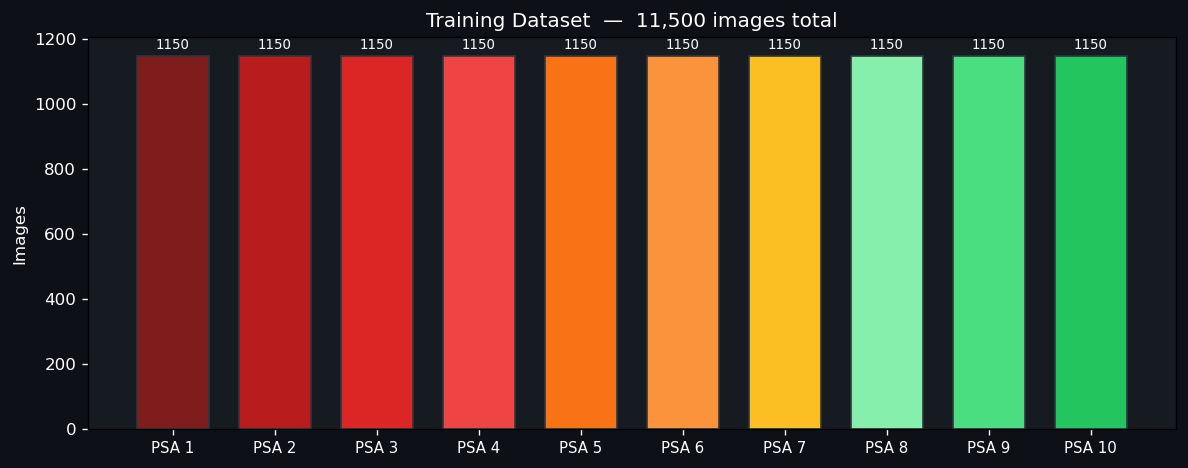

✅ train.txt: 10350 images
   val.txt:   1150 images

Starting ResNet-18 training …
Training requires PyTorch: name 'train_resnet_grader' is not defined
Install: pip install torch torchvision


In [6]:
import shutil, csv
from pathlib import Path
from collections import Counter, defaultdict

UNIFIED_DIR = Path('datasets/unified')


def merge_datasets(sources: list[Path] = None,
                   dest: Path = UNIFIED_DIR,
                   min_dim: int = 100) -> dict:
    """
    Copy images from each source folder into dest/psa{1-10}/ subfolders.

    sources: list of root dirs, each containing psa1/ … psa10/ subfolders.
             Defaults to all three collected sources.
    min_dim: skip images smaller than this (corrupt / too small)
    """
    if sources is None:
        sources = [
            Path('datasets/PSA-Grades-Baseball'),
            Path('datasets/pokemon_psa'),
            Path('datasets/pokemon_ebay'),
        ]

    dest.mkdir(parents=True, exist_ok=True)
    counts  = defaultdict(lambda: defaultdict(int))  # source → grade → count
    skipped = 0

    for src_root in sources:
        src_name = src_root.name
        if not src_root.exists():
            print(f'  ⚠ Skipping {src_root} (not found)')
            continue

        for grade in range(1, 11):
            # Accept psa9/ or grade_9/ or 9/
            for folder_name in (f'psa{grade}', f'grade_{grade}', str(grade)):
                folder = src_root / folder_name
                if not folder.exists():
                    continue
                for img_path in folder.glob('*'):
                    if img_path.suffix.lower() not in ('.jpg','.jpeg','.png','.webp'):
                        continue
                    # Quick dimension check
                    if min_dim > 0:
                        try:
                            import cv2 as _cv2
                            im = _cv2.imread(str(img_path))
                            if im is None or min(im.shape[:2]) < min_dim:
                                skipped += 1
                                continue
                        except Exception:
                            pass
                    dest_folder = dest / f'psa{grade}'
                    dest_folder.mkdir(exist_ok=True)
                    # Prefix with source name to avoid collisions
                    new_name = f'{src_name}_{img_path.name}'
                    target   = dest_folder / new_name
                    if not target.exists():
                        shutil.copy2(img_path, target)
                    counts[src_name][grade] += 1

    # ── Stats report ─────────────────────────────────────────────
    all_by_grade = defaultdict(int)
    for src, grade_counts in counts.items():
        for g, n in grade_counts.items():
            all_by_grade[g] += n

    print(f'\n{"━"*56}')
    print(f'  Unified dataset  →  {dest}')
    print(f'{"━"*56}')
    total = sum(all_by_grade.values())
    for grade in range(1, 11):
        n   = all_by_grade[grade]
        bar = '█' * (n // max(total // 200, 1))
        print(f'  PSA {grade:>2}  {n:>6} images  {bar}')
    print(f'{"─"*56}')
    print(f'  Total            {total:>6} images')
    if skipped:
        print(f'  Skipped (too small/corrupt): {skipped}')
    print()

    # Per-source breakdown
    for src, grade_counts in counts.items():
        src_total = sum(grade_counts.values())
        print(f'  {src:<35} {src_total:>5} images')

    return dict(all_by_grade)


def plot_dataset_distribution(by_grade: dict):
    """Bar chart of the merged dataset grade distribution."""
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    grades = list(range(1, 11))
    counts = [by_grade.get(g, 0) for g in grades]
    colors = [GRADE_COLORS.get(g, '#888') for g in grades]

    bars = ax.bar(grades, counts, color=colors, width=0.7, edgecolor='#30363d')
    ax.set_xticks(grades)
    ax.set_xticklabels([f'PSA {g}' for g in grades], color='white', fontsize=9)
    ax.set_ylabel('Images', color='white')
    ax.set_title(f'Training Dataset  —  {sum(counts):,} images total',
                 color='white', fontsize=12)
    ax.tick_params(colors='white')
    for bar, n in zip(bars, counts):
        if n:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    str(n), ha='center', color='white', fontsize=8)
    plt.tight_layout()
    plt.show()


def train_val_split(unified_dir: Path = UNIFIED_DIR,
                    val_frac: float = 0.10) -> tuple[int, int]:
    """
    Write train.txt and val.txt listing image paths and labels.
    Returns (n_train, n_val).
    """
    import random
    rng = random.Random(42)
    train_lines, val_lines = [], []

    for grade in range(1, 11):
        folder = unified_dir / f'psa{grade}'
        if not folder.exists(): continue
        paths = [str(p) for p in sorted(folder.glob('*')) if p.is_file()]
        rng.shuffle(paths)
        split = max(1, int(len(paths) * val_frac))
        val_lines  += [f'{p}\t{grade}' for p in paths[:split]]
        train_lines += [f'{p}\t{grade}' for p in paths[split:]]

    (unified_dir / 'train.txt').write_text('\n'.join(train_lines))
    (unified_dir / 'val.txt').write_text('\n'.join(val_lines))
    print(f'✅ train.txt: {len(train_lines)} images')
    print(f'   val.txt:   {len(val_lines)} images')
    return len(train_lines), len(val_lines)


# ── Run everything ────────────────────────────────────────────────
by_grade = merge_datasets()

if sum(by_grade.values()) > 0:
    plot_dataset_distribution(by_grade)
    n_train, n_val = train_val_split()

    # Kick off training if we have enough data
    if n_train >= 100:
        print('\nStarting ResNet-18 training …')
        try:
            model, history = train_resnet_grader(
                image_dir   = str(UNIFIED_DIR),
                model_out   = 'resnet18_grader.pt',
                num_classes = 5,
                epochs      = 10,
                batch_size  = 32,
            )
        except Exception as e:
            print(f'Training requires PyTorch: {e}')
            print('Install: pip install torch torchvision')
    else:
        print(f'\nNeed more images before training (have {n_train}).')
        print('Run Sections 27 and 28 to collect more data, then re-run this cell.')
else:
    print('No images merged yet — run Sections 26, 27, 28 first.')